In [2]:
#from a fieldmap in straight coordinates to one in curved coordinates
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
import bpmeth
from sympy import lambdify 
from sympy.abc import x, y, s

(0.0, 1.0)

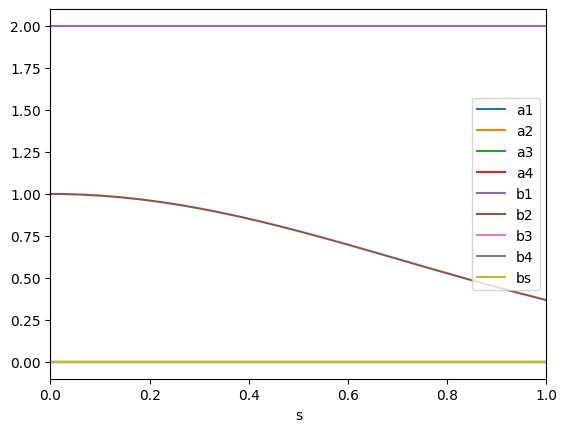

In [40]:
#start from multipole coeefficients a_n(s)=a1,a2,... and b_n(s)
a_coeffs = [0, 0, 0, 0]
b_coeffs = [2,"exp(-s**2)",0, 0]
#get scalar potential
expansion=bpmeth.FieldExpansion(a=a_coeffs, b=b_coeffs)
expansion.plot_components()
plt.xlabel('s')
plt.xlim((0,1))

Scalar potential phi(x,y,s): -x*y**3*(2*s**2 - 1)*exp(-s**2)/3 + y*(6*x*exp(-s**2) + 12)/6
Scalar potential phi at (0.4,0.2,0.5): 0.46271942306335045


/home/fmarcoli/bpmeth/src/bpmeth/generate_expansion.py:94: UserWarning: More terms are needed in the expansion for aperture 0.05m, the laplacian is -0.0000123442050462438
  warnings.warn(f"More terms are needed in the expansion for aperture {apperture}m, the laplacian is {laplval}")


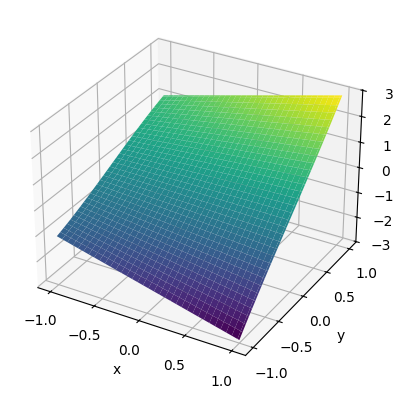

In [41]:
phi=expansion.get_phi()
print("Scalar potential phi(x,y,s):", phi)

XYS=(x,y,s)#symbolic expressions

phi_func = lambdify(XYS, phi, 'numpy')#from symbolic to numerical function
print("Scalar potential phi at (0.4,0.2,0.5):", phi_func(0.4,0.2,0.5))
#define x,y,s axes to convert the symbolic expression of phi into a numerical array
xa= np.linspace(-1,1,101)
ya=np.linspace(-1,1,101)
sa=np.linspace(-1,1,101)
#make a 3d plot of phi as a function of x and y for a fixed s
X, Y = np.meshgrid(xa, ya)
P = phi_func(X, Y, 0.5)#s=0.5 is the middle  of the magnet
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, P, cmap='viridis')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('phi(x,y,s=0.5)')
plt.show()

In [42]:
# Get analytical B field functions
Bx_func, By_func, Bs_func = expansion.get_Bfield(lambdify=True)
#print("Bx:", Bx_func, "By:", By_func, "Bs:", Bs_func)
# Evaluate on grid
X,Y,S = np.meshgrid(xa, ya, sa)
Bx_ana = Bx_func(X, Y, S)
By_ana = By_func(X, Y, S)
Bs_ana = Bs_func(X, Y, S)
#print("Bx shape:", Bx_ana.shape, "By shape:", By_ana.shape, "Bs shape:", Bs_ana.shape)
# X, Y, S  from meshgrid in straight frame
# Bx_ana, By_ana, Bs_ana are the corresponding field arrays
datafieldmap = np.column_stack([
    X.ravel(),
    Y.ravel(),
    S.ravel(),
    Bx_ana.ravel(),
    By_ana.ravel(),
    Bs_ana.ravel()
])
#print("Data shape (N, 6):", datafieldmap.shape)
fm = bpmeth.fieldmaps.Fieldmap(datafieldmap)
#print(xa.shape)

In [66]:
rho = .5
phi = 1.
xFS = np.linspace(-0.05, 0.05, 101)
yFS = np.linspace(-0.05, 0.05, 101)
sFS = np.linspace(-rho*phi, rho*phi, 103)
interp_rad=0.025
fm_fs = fm.calc_FS_coords(xFS, yFS, sFS, rho, phi, radius=interp_rad)

/home/fmarcoli/bpmeth/src/bpmeth/fieldmaps.py:128: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  self.src.plot(scalars=field)


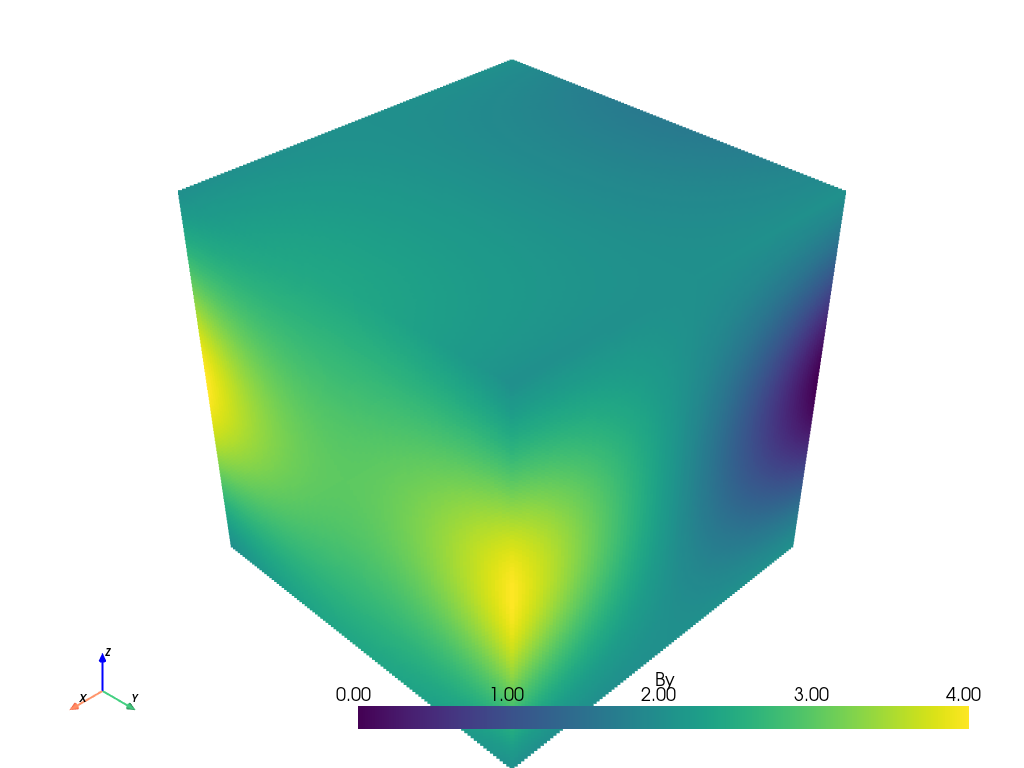

In [67]:
fm.plot(field="By")

/home/fmarcoli/bpmeth/src/bpmeth/fieldmaps.py:128: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  self.src.plot(scalars=field)


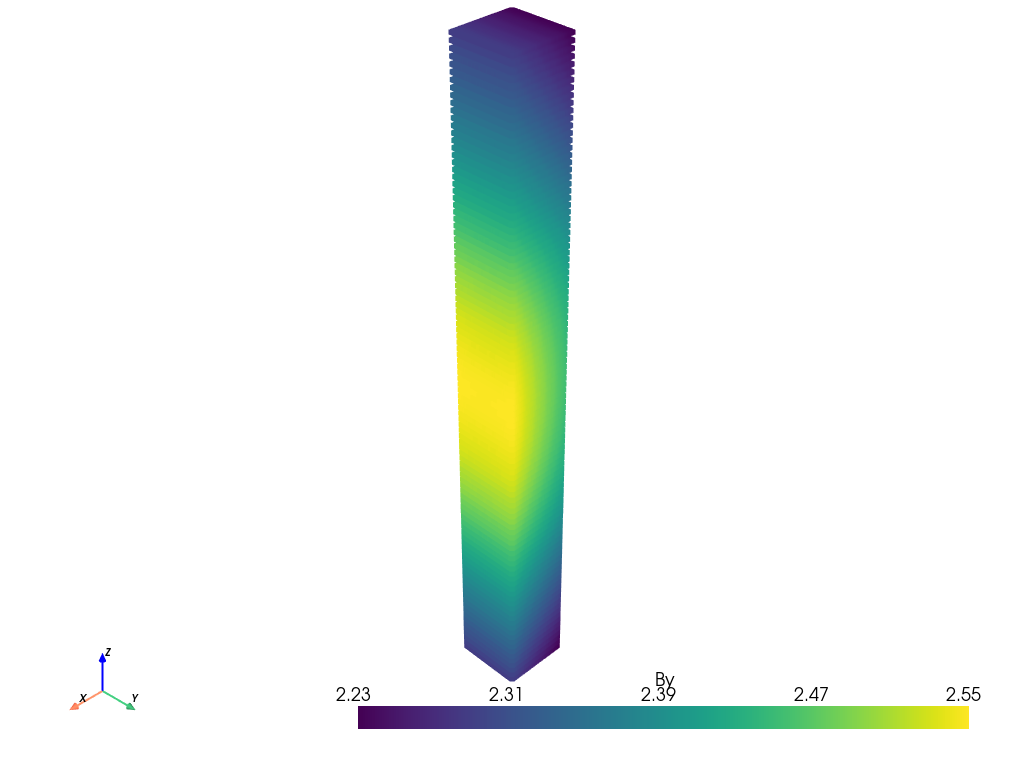

In [68]:
fm_fs.plot(field="By")

/home/fmarcoli/bpmeth/src/bpmeth/fieldmaps.py:128: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  self.src.plot(scalars=field)


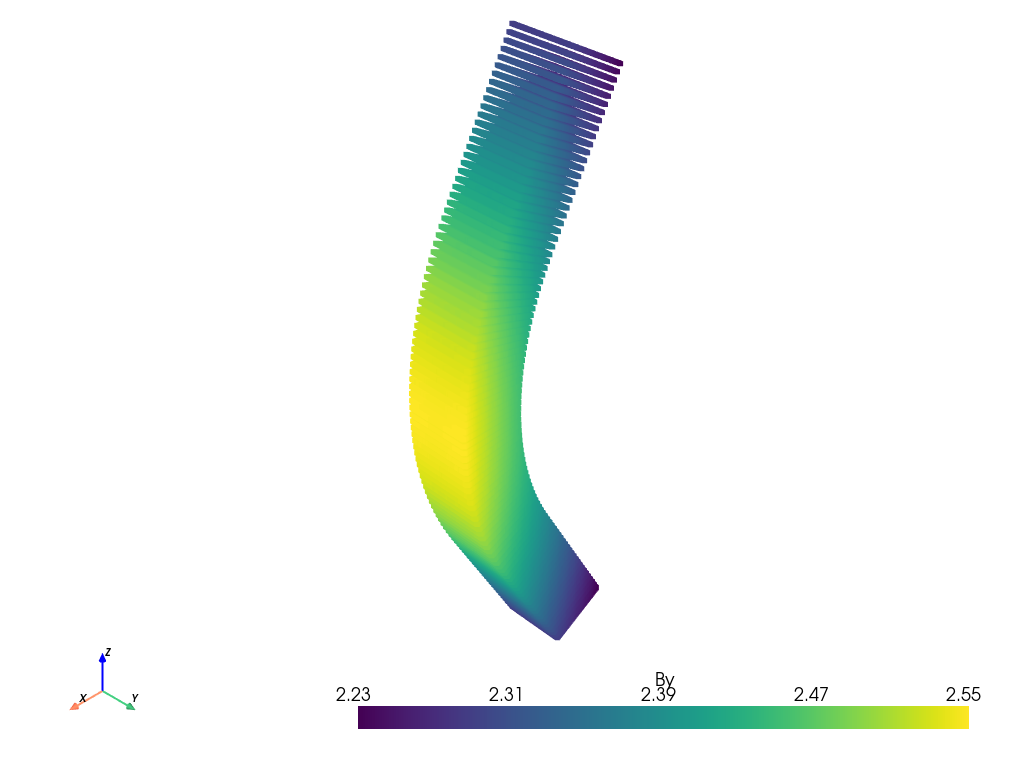

In [69]:
fm.FS_frame_plot(
    rho,
    phi,
    field="By",
    radius=interp_rad,#of interpolation
    xmax=0.05,
    ymax=0.05,
    nx=100,
    ny=100,
    ns=100
)

Now i can extract the multipole coefficients using derivatives on axis in the FS frame

In [70]:
#extract Bx from the fieldmap object 
Bx_fs = fm_fs.get_data()[:,3] #the 4th column is Bx
By_fs = fm_fs.get_data()[:,4] #the 5th column is By
print("Bx_fs shape:", Bx_fs.shape)
print("xFS shape:", xFS.shape)
print( len(xFS) * len(yFS) * len(sFS))
Bx_fs_reshaped = Bx_fs.reshape(len(xFS), len(yFS), len(sFS))
By_fs_reshaped = By_fs.reshape(len(xFS), len(yFS), len(sFS))
print("Bx_fs reshaped shape:", Bx_fs_reshaped.shape)

def derivativesFromField(x, B_i, max_order): #_i= x or y, B_i is the 3d array of the field component evaluated on the grid, max_order is the maximum order of derivative to compute
    dBvector=np.zeros((max_order+1, len(B_i),len(sFS)))
    dBvector[0,:,:] = B_i[:, B_i.shape[1]//2, :] #take the field at y=0, keep x,s dependence
    for i in range(1,max_order+1):
        dBvector[i,:,:]=np.gradient(dBvector[i-1,:,:], x, axis=0)
    return dBvector

max_order = 2
idx_zero = np.argmin(np.abs(xFS))
dBFSxvector=derivativesFromField(xFS, Bx_fs_reshaped, max_order)
dBFSyvector=derivativesFromField(xFS, By_fs_reshaped, max_order)


Bx_fs shape: (1050703,)
xFS shape: (101,)
1050703
Bx_fs reshaped shape: (101, 101, 103)


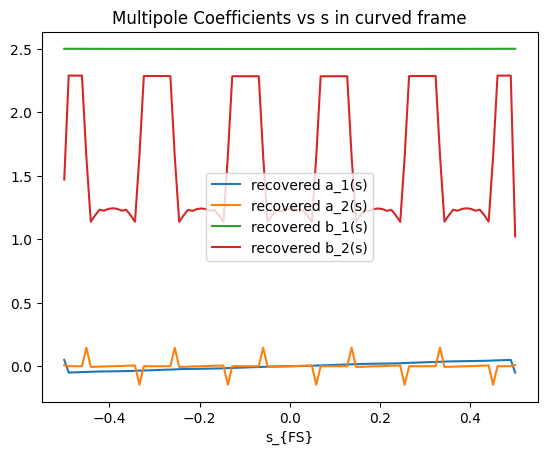

 b_n(s) in the straight frame: [2, 'exp(-s**2)', 0, 0]
a_n(s) in the straight frame: [0, 0, 0, 0]


In [71]:
a_nnew=np.zeros((max_order,len(sFS)))
b_nnew=np.zeros((max_order,len(sFS)))
a_nnew[:,:]=dBFSxvector[:max_order,idx_zero,:]
b_nnew[:,:]=dBFSyvector[:max_order,idx_zero,:]

plt.plot(sFS, a_nnew[0,:], label='recovered a_1(s)')
plt.plot(sFS, a_nnew[1,:], label='recovered a_2(s)')
#plt.plot(sFS, a_nnew[2,:], label='recovered a_3(s)')
plt.plot(sFS, b_nnew[0,:], label='recovered b_1(s)')
plt.plot(sFS, b_nnew[1,:], label='recovered b_2(s)')
#plt.plot(sFS, b_nnew[2,:], label='recovered b_3(s)')
plt.xlabel('s_{FS}')
plt.legend()
plt.title('Multipole Coefficients vs s in curved frame')
plt.show()
print(" b_n(s) in the straight frame:", b_coeffs)
print("a_n(s) in the straight frame:", a_coeffs)
